# **Data Mining and Machine Learning**
# **Assignment 1** 

#### **Submitted by:**  
### ~ Arushi Marwaha (MDS202512)
### ~ Deepta Basak (MDS202517)

#### **Course:** MSc Data Science 1  
----


## Task 1: Bank Marketing Campaign 
---
### Objective

The objective of this task is to build two classification models:

* A Decision Tree classifier

* A Naïve Bayes classifier

The goal is to predict whether a client will subscribe to a term deposit (y variable).

Since the dataset is imbalanced, we evaluate models using:

* Precision

* Recall

* F1-score

F1-score is used as the primary metric because it balances precision and recall.

# Dataset Description:

The dataset used is the Bank Marketing Dataset from the UCI Machine Learning Repository.

The data is related to direct marketing campaigns (phone calls) of a Portuguese banking institution. The goal is to predict whether a client will subscribe to a term deposit (y variable).

Number of instances: 45,211
Number of attributes: 16 input attributes + 1 output attribute


As required by the dataset creators:
S. Moro, R. Laureano and P. Cortez. Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology. ESM 2011. 

# Exploratory Data Analysis

## Load Dataset

In [437]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/mindpalace/Documents/repositories/dmml-assignment1/data/bank-additional-full.csv", sep = ";")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Checking basic structure of the dataset:

In [438]:
df.shape

(41188, 21)

In [439]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

## Observations from Dataset Structure

The dataset contains a mix of:

* Numerical variables (e.g., age, campaign, pdays)

* Categorical variables (e.g., job, marital, education)

There are no missing values in the traditional sense, but some categorical features contain the value "unknown", which represents missing or unavailable information.

The target variable y is categorical (yes/no), which we later convert into binary form.

# Dataset memory usage (before encoding)

In [440]:
# Memory usage of original dataset
memory_df = df.memory_usage(deep=True).sum() / (1024**2)
print("Memory usage of original dataset (MB):", memory_df)

Memory usage of original dataset (MB): 30.260939598083496


## Target Distribution

In [441]:
df['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [442]:
df['y'].value_counts(normalize = True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

## Data Leakage

The variable duration represents the length of the phone call. Since this value is only known after the call has been completed, including it in the model would introduce data leakage.

Removing it ensures that our model reflects a realistic prediction setting.

In [443]:
df = df.drop(columns=['duration'])

## Explore numeric features

In [444]:
df.describe()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## Explore categorical features

In [445]:
for col in df.select_dtypes(include='object').columns:
    print(col)
    print(df[col].value_counts())
    print()

job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

contact
contact
cel

/var/folders/gs/609qt8vn5r5_85hyvyb5yyr00000gn/T/ipykernel_3904/1464506494.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


## Class Imbalance Visualization

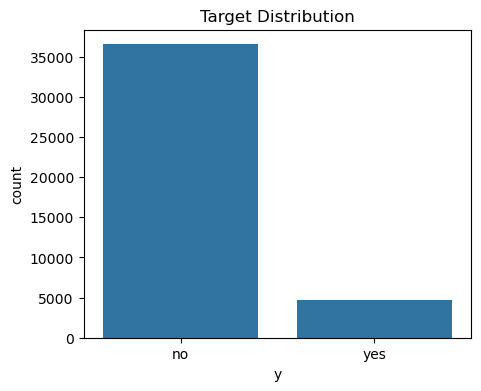

In [446]:
plt.figure(figsize=(5,4))
sns.countplot(x='y', data=df)
plt.title("Target Distribution")
plt.show()

## Observation

As we observed from the target distribution and the above visualization, the dataset is imbalanced — majority class is "no". This means that a model predicting "no" for every instance would achieve high accuracy. Therefore, accuracy alone is not a sufficient metric. 

We will focus on the following metrics:

* Precision

* Recall

* F1-score

These metrics better capture performance on the minority class ("yes"). F1-score is chosen because it balances precision and recall.

# Data Pre-Processing

Decision Trees can handle categorical data if encoded.
Naive Bayes in sklearn requires the input data to be numeric.

## Train/Test Split

In [447]:
X = df.drop(columns=['y'])
y = df['y'].map({'no':0, 'yes':1})

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## One-hot encoding

In [448]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align test columns with train columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

## Explanation of One-Hot Encoding

Categorical variables are converted into binary indicator variables using one-hot encoding.

This ensures:

* Decision Tree can split on categorical values correctly.

* Naïve Bayes can compute probabilities on binary features.

* The test set is aligned with the training set to ensure both have identical feature columns.

# Memory usage after One-Hot Encoding

In [449]:
# Memory usage after one-hot encoding (training + test)
memory_train = X_train.memory_usage(deep=True).sum() / (1024**2)
memory_test = X_test.memory_usage(deep=True).sum() / (1024**2)

print("Memory usage of X_train (MB):", memory_train)
print("Memory usage of X_test (MB):", memory_test)
print("Total memory after encoding (MB):", memory_train + memory_test)

Memory usage of X_train (MB): 3.381932258605957
Memory usage of X_test (MB): 1.531991958618164
Total memory after encoding (MB): 4.913924217224121


# Decision Tree Classifier

# Effect of Tree Depth on Performance

In [450]:
from sklearn.model_selection import cross_val_score

depths = [3, 5, 7, 10]
cv_mean_scores = {}

for d in depths:
    model = DecisionTreeClassifier(
        criterion='gini',
        max_depth=d,
        random_state=42
    )
    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1'
    )
    
    cv_mean_scores[d] = scores.mean()
    print(f"Depth {d} - Mean CV F1-score: {scores.mean()}")

best_depth = max(cv_mean_scores, key=cv_mean_scores.get)
print("Best Depth based on CV:", best_depth)

Depth 3 - Mean CV F1-score: 0.30052278653664377
Depth 5 - Mean CV F1-score: 0.37495267481203304
Depth 7 - Mean CV F1-score: 0.37611095641917486
Depth 10 - Mean CV F1-score: 0.3670389973546016
Best Depth based on CV: 7


From cross-validation results, depth = 7 achieved the highest mean F1-score.

Although the improvement over depth = 5, our original choice, is small, depth = 7 provides the best average performance across folds. Therefore, we select max_depth = 7 as the final model configuration.

The decrease in performance at depth = 10 suggests the beginning of overfitting.

In [451]:
from sklearn.tree import DecisionTreeClassifier

dt_gini = DecisionTreeClassifier(
    criterion='gini',
    max_depth=best_depth,
    random_state=42
)

import time

start = time.time()
dt_gini.fit(X_train, y_train)
dt_gini_train_time = time.time() - start

print("Decision Tree (Gini) Training Time (seconds):", dt_gini_train_time)

Decision Tree (Gini) Training Time (seconds): 0.053320884704589844


In [452]:
dt_gini.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

## Predictions

In [453]:
y_pred_dt_gini = dt_gini.predict(X_test)

## Model 2: Using Entropy

In [454]:
dt_entropy = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

start = time.time()
dt_entropy.fit(X_train, y_train)
dt_entropy_train_time = time.time() - start

print("Decision Tree (Entropy) Training Time (seconds):", dt_entropy_train_time)

Decision Tree (Entropy) Training Time (seconds): 0.03914809226989746


In [455]:
dt_entropy.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

## Predictions

In [456]:
y_pred_dt_entropy = dt_entropy.predict(X_test)

## Why Compare Gini and Entropy?

Both Gini index and Entropy measure impurity. We compare them to observe whether the choice of impurity measure significantly affects model performance.

# Naive Bayes Classifier

## Train Model

In [457]:
from sklearn.naive_bayes import BernoulliNB

nb = BernoulliNB(alpha=1)  # Laplace smoothing

start = time.time()
nb.fit(X_train, y_train)
nb_train_time = time.time() - start

print("Naive Bayes Training Time (seconds):", nb_train_time)

Naive Bayes Training Time (seconds): 0.014182090759277344


In [458]:
nb.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


## Predictions

In [459]:
y_pred_nb = nb.predict(X_test)

# Prediction Time Comparison

In addition to training time, we measure prediction time on the test set. This provides a complete comparison of computational efficiency.

# Evaluation

## Confusion Matrix and Classification Report

In [460]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score

print("Decision Tree (Gini)")
print(confusion_matrix(y_test, y_pred_dt_gini))
print(classification_report(y_test, y_pred_dt_gini))

print("\nDecision Tree (Entropy)")
print(confusion_matrix(y_test, y_pred_dt_entropy))
print(classification_report(y_test, y_pred_dt_entropy))

print("\nNaive Bayes (Bernoulli)")
print(confusion_matrix(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Decision Tree (Gini)
[[10749   216]
 [ 1017   375]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.95     10965
           1       0.63      0.27      0.38      1392

    accuracy                           0.90     12357
   macro avg       0.77      0.62      0.66     12357
weighted avg       0.88      0.90      0.88     12357


Decision Tree (Entropy)
[[10766   199]
 [ 1010   382]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.95     10965
           1       0.66      0.27      0.39      1392

    accuracy                           0.90     12357
   macro avg       0.79      0.63      0.67     12357
weighted avg       0.89      0.90      0.88     12357


Naive Bayes (Bernoulli)
[[9956 1009]
 [ 843  549]]
              precision    recall  f1-score   support

           0       0.92      0.91      0.91     10965
           1       0.35      0.39      0.37      1392

    accuracy          

## Interpreting the Confusion Matrix

The confusion matrix shows:

* True Positives (TP): Correctly predicted subscriptions

* True Negatives (TN): Correctly predicted non-subscriptions

* False Positives (FP): Incorrectly predicted subscriptions

* False Negatives (FN): Missed actual subscriptions

For marketing campaigns, False Negatives are particularly important because they represent missed potential customers.

## Interpreting Precision, Recall and F1-score

Precision measures how many predicted "yes" are actually correct.

Recall measures how many actual "yes" cases were identified.

F1-score balances both precision and recall.

Since the dataset is imbalanced, F1-score is used as the primary evaluation metric.

## F1 Score Comparison

In [461]:
f1_gini = f1_score(y_test, y_pred_dt_gini)
f1_entropy = f1_score(y_test, y_pred_dt_entropy)
f1_nb = f1_score(y_test, y_pred_nb)

print("F1 Score (Decision Tree - Gini):", f1_gini)
print("F1 Score (Decision Tree - Entropy):", f1_entropy)
print("F1 Score (Naive Bayes):", f1_nb)

F1 Score (Decision Tree - Gini): 0.37821482602118
F1 Score (Decision Tree - Entropy): 0.387227572225038
F1 Score (Naive Bayes): 0.3722033898305085


# Confusion Matrix Visualization

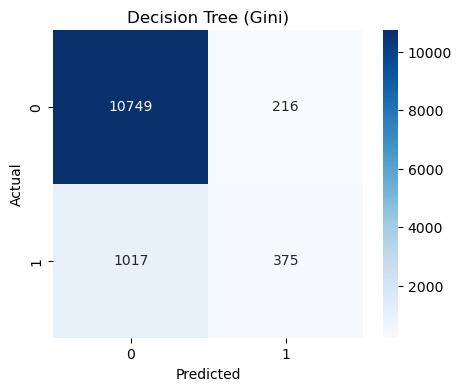

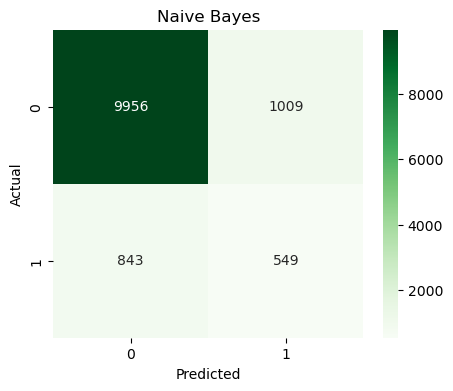

In [462]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt_gini),
            annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree (Gini)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_nb),
            annot=True, fmt='d', cmap='Greens')
plt.title("Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Importance (Decision Tree)

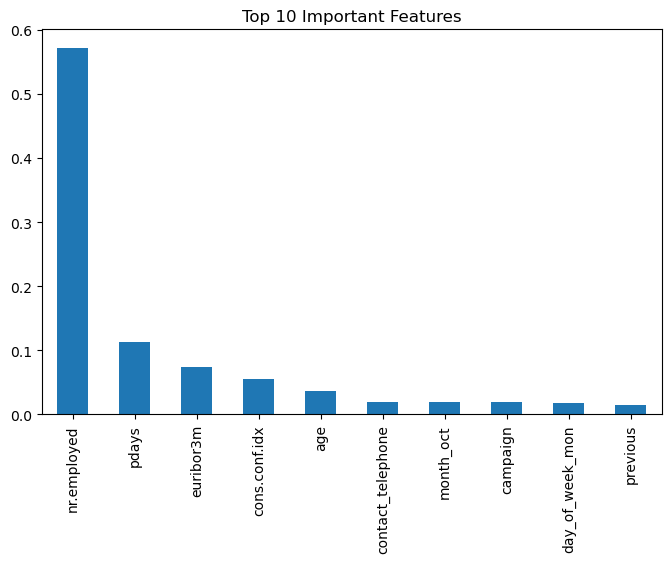

In [463]:
importances = pd.Series(
    dt_gini.feature_importances_,
    index=X_train.columns
)

top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_features.plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

## Interpretation of Feature Importance

The bar chart shows the top features contributing to impurity reduction. Features near the top of the chart have the greatest influence on classification decisions. This provides interpretability, allowing us to understand which factors are most predictive of subscription.

# Overfitting Analysis

In [464]:
from sklearn.metrics import f1_score

print("Decision Tree - Training F1:",
      f1_score(y_train, dt_gini.predict(X_train)))
print("Decision Tree - Test F1:",
      f1_score(y_test, y_pred_dt_gini))

print("Naive Bayes - Training F1:",
      f1_score(y_train, nb.predict(X_train)))
print("Naive Bayes - Test F1:",
      f1_score(y_test, y_pred_nb))

Decision Tree - Training F1: 0.42973785990545765
Decision Tree - Test F1: 0.37821482602118
Naive Bayes - Training F1: 0.3655456222506031
Naive Bayes - Test F1: 0.3722033898305085


## Interpretation of Training vs Test Accuracy

If training accuracy is significantly higher than test accuracy, the model may be overfitting. The selected depth (7) balances model complexity and generalization. Comparing training and test performance allows us to assess generalization.

# Comparative Analysis

1. The dataset is imbalanced; therefore accuracy is not sufficient for evaluation.

2. F1-score is used to evaluate performance on the minority class.

3. Decision Tree achieves higher F1-score compared to Naïve Bayes.

4. Gini and Entropy yield similar performance, indicating that impurity measure choice has limited impact here.

5. Naïve Bayes assumes independence among features, which may not hold in this dataset.

6. Decision Tree captures interactions between features and provides better predictive performance.

7. Decision Tree also provides feature importance, improving interpretability.

8. Naïve Bayes is computationally simpler and faster.

# Computational Details

* Train/Test split: 70%-30%

* Decision Tree: max_depth = 7 (selected using 5-fold cross-validation)

* Criteria compared: Gini and Entropy

* Naive Bayes: BernoulliNB with Laplace smoothing (alpha = 1)

* Evaluation metric: F1-score

# Overview

## Parameters Used

* Train/Test split: 70%-30%

* Decision Tree:

    * Criterion: Gini and Entropy

    * max_depth = 7

* Naïve Bayes:

    * BernoulliNB

    * alpha = 1 (Laplace smoothing)

## Time Taken

Decision Tree training involves searching for optimal splits based on impurity reduction and therefore takes longer.

Naïve Bayes training is faster because it estimates class probabilities and conditional probabilities directly.

## Space Required

The original dataset occupies approximately 30.26 MB in memory.

After one-hot encoding, the training and test sets together occupy approximately 4.91 MB.

The reduction in memory occurs because categorical string variables (object dtype) consume significantly more memory than numeric binary columns created during one-hot encoding. Converting string-based categories into compact numeric representations reduces memory usage despite increasing the number of columns.

## Comparative Evaluation

Decision Tree achieved higher F1-score compared to Naïve Bayes.

Naïve Bayes performs reasonably well but is limited by its independence assumption.

Decision Tree provides stronger predictive performance and better interpretability for this dataset.